# DEEP NEURAL NETWORKS - ASSIGNMENT 2: CNN FOR IMAGE CLASSIFICATION

## Convolutional Neural Networks: Custom Implementation vs Transfer Learning

"""
ASSIGNMENT OVERVIEW

This assignment requires you to implement and compare two CNN approaches for
image classification:
1. Custom CNN architecture using Keras/PyTorch
2. Transfer Learning using pre-trained models (ResNet/VGG)

Learning Objectives:
- Design CNN architectures with Global Average Pooling
- Apply transfer learning with pre-trained models
- Compare custom vs pre-trained model performance
- Use industry-standard deep learning frameworks

IMPORTANT: Global Average Pooling (GAP) is MANDATORY for both models.
DO NOT use Flatten + Dense layers in the final architecture.
"""

In [ ]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os

In [ ]:
# Deep learning frameworks (choose Keras or PyTorch)
# For image processing
from PIL import Image
import cv2
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from pathlib import Path
from tensorflow.keras import models, layers
import random


target_classes = [
    'Corn___Gray_Leaf_Spot',
    'Corn___Healthy',
    'Corn___Northern_Leaf_Blight',
    'Rice___Leaf_Blast',
    'Rice___Neck_Blast'
]

2026-02-08 19:59:30.052615: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-08 19:59:30.122567: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-08 19:59:31.807779: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# import os suggested for cache no space in transfer model

# # Create a new cache directory on your large NVMe mount
# os.makedirs('/mnt/img_data/keras_cache', exist_ok=True)

# # Point Keras/TensorFlow to the new location
# os.environ['TF_HOME'] = '/mnt/img_data/keras_cache'
# os.environ['KERAS_HOME'] = '/mnt/img_data/keras_cache'

# print("✅ Keras cache redirected to /mnt/img_data/keras_cache")

In [ ]:
#GPU check here
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Detected: {gpus}")
else:
    print("❌ GPU NOT detected. TensorFlow will fall back to CPU.")

✅ GPU Detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Define Global Constants

IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)
BATCH_SIZE = 32
RANDOM_SEED = 42
NUM_CLASSES = 5

### 1.1 Dataset Selection and Loading

 : Load your chosen dataset

In [ ]:
# REQUIRED: Fill in these metadata fields
dataset_name = "Plant Disease"
dataset_source = "Kaggle"
n_samples = 3500
n_classes = 5
samples_per_class = 700
image_shape = INPUT_SHAPE  # [height, width, channels]
problem_type = "classification"


# Load and get basic info
#data_dir = 'D:\\MyProjects\\ML_Study\\ML_as2\\dataset\\crop_disease'
data_dir = '/mnt/img_data/crop_disease'
# change to '/dataset/crop_disease' when running in a different environment

dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels='inferred',
    label_mode='categorical',
    class_names=target_classes, # Only loads these 5
    image_size=IMG_SIZE,
    batch_size=32
)

class_names = dataset.class_names
print(f"Class names: {class_names}")

# The shape of the batches can be inspected
for image_batch, label_batch in dataset.take(1):
    print(f"Image batch shape: {image_batch.shape}")
    print(f"Label batch shape: {label_batch.shape}")

Found 4637 files belonging to 5 classes.


I0000 00:00:1770560972.640068    6346 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13616 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


Class names: ['Corn___Gray_Leaf_Spot', 'Corn___Healthy', 'Corn___Northern_Leaf_Blight', 'Rice___Leaf_Blast', 'Rice___Neck_Blast']
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 5)


2026-02-08 19:59:34.368287: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# Primary metric selection
primary_metric = "recall"
metric_justification = """
Recall is the metric where False Negatives are minimized. Since the cost of not detecting diseased plant is more catastropic
for the entire field, recall is chosen as the desired metric to evaluate the model.
"""

In [ ]:
print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

DATASET INFORMATION
Dataset: Plant Disease
Source: Kaggle
Total Samples: 3500
Number of Classes: 5
Samples per Class: 700
Image Shape: (224, 224, 3)
Primary Metric: recall
Metric Justification: 
Recall is the metric where False Negatives are minimized. Since the cost of not detecting diseased plant is more catastropic
for the entire field, recall is chosen as the desired metric to evaluate the model.



### 1.2 Data Exploration and Visualization

-  : Show sample images from each class
-  : Plot class distribution
-  : Display image statistics

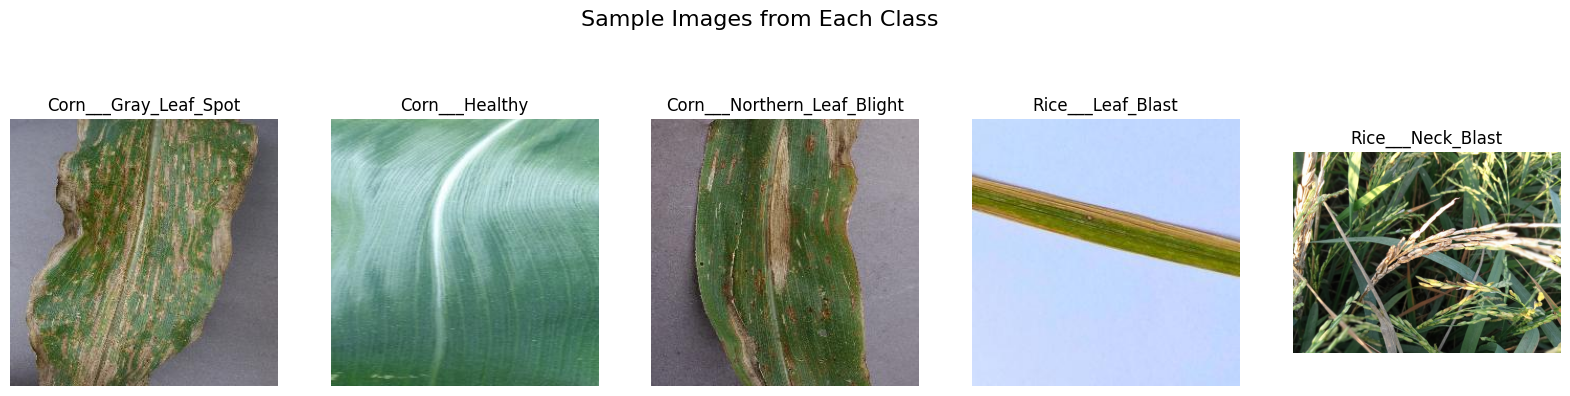

2026-02-08 19:59:55.770501: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


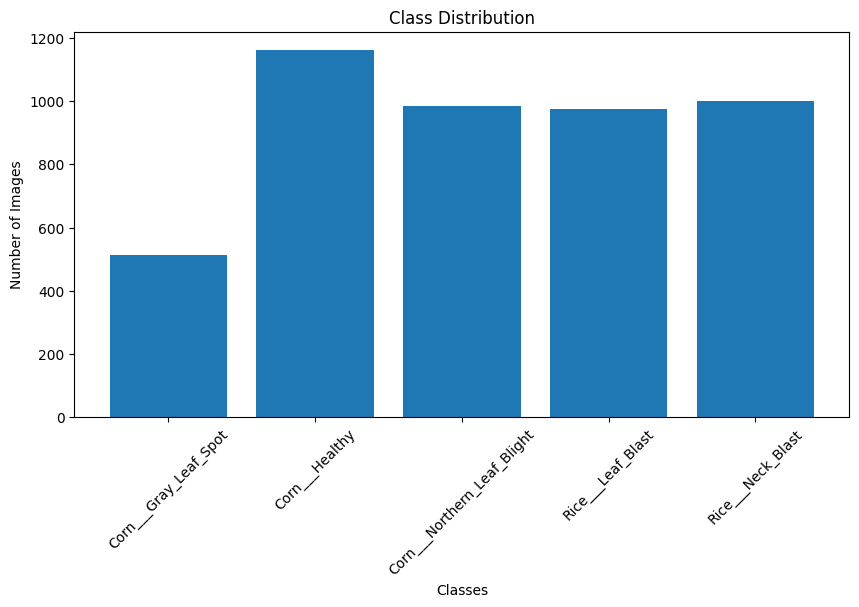

In [ ]:
#   1:show sample images from each class

plt.figure(figsize=(20, 5))
plt.suptitle("Sample Images from Each Class", fontsize=16)
for i in range(len(class_names)):
    class_name = class_names[i]
    folder_path = os.path.join(data_dir, class_name)
    img_name = os.listdir(folder_path)[0]
    img_path = os.path.join(folder_path, img_name)

    # Plot
    plt.subplot(1, len(class_names), i + 1)
    img = plt.imread(img_path)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.show()

#  2: Plot class distribution

class_counts = [0] * len(class_names)
for images, labels in dataset:
    for label in labels:
        class_idx = tf.argmax(label).numpy()
        class_counts[class_idx] += 1

plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

#  3:Display image statistics (mean, std, min, max)
normalization_layer = tf.keras.layers.Rescaling(1./255)


### 1.3 Data Preprocessing
-  : Resize images to consistent size
-  : Normalize pixel values
-  : Split into train/test (90/10 or 85/15)

In [ ]:
def get_balanced_paths(data_dir, classes, n_samples):
    all_paths = []
    all_labels = []

    for i, class_name in enumerate(classes):
        class_path = data_dir + "/" + class_name
        # Get all image files in the directory
        class_path = Path(class_path)
        images = list(class_path.glob('*.JPG')) + list(class_path.glob('*.jpg')) + list(class_path.glob('*.png'))

        # Randomly sample 700
        sampled_images = random.sample(images, n_samples)

        all_paths.extend([str(p) for p in sampled_images])
        all_labels.extend([i] * n_samples)

    return all_paths, all_labels

image_paths, labels = get_balanced_paths(data_dir, class_names, 500)

In [ ]:
# REQUIRED: Document your split
train_test_ratio = "90/10"
train_samples = 2250
test_samples = 250

combined = list(zip(image_paths, labels))
random.shuffle(combined)
image_paths, labels = zip(*combined)

total_size = len(image_paths)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
# Test size is the remainder

# 3. Perform the 3-way Split
train_paths = image_paths[:train_size]
train_labels = labels[:train_size]

val_paths = image_paths[train_size : train_size + val_size]
val_labels = labels[train_size : train_size + val_size]

test_paths = image_paths[train_size + val_size:]
test_labels = labels[train_size + val_size:]

# 4. TensorFlow Dataset Functions
def process_path(file_path, label):
    # Load raw data
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    # Resize and Rescale (Normalization)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

def create_dataset(paths, labels):
    labels = tf.keras.utils.to_categorical(labels, num_classes=n_classes)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(list(train_paths), list(train_labels))
val_ds = create_dataset(list(val_paths), list(val_labels))
test_ds = create_dataset(list(test_paths), list(test_labels))


In [ ]:
print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")


Train/Test Split: 90/10
Training Samples: 2250
Test Samples: 250


### 2.1 Custom CNN Architecture Design
-  : Define your CNN architecture
-  : Ensure Global Average Pooling is included (MANDATORY)
-  : Use Conv2D, MaxPooling2D/AvgPooling2D, GlobalAveragePooling2D, Dense

In [ ]:
def build_custom_cnn(input_shape, n_classes):
    """
    Build custom CNN architecture

    Args:
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: compiled CNN model
    """
    #  : Implement your CNN architecture
    # Must include Global Average Pooling
    model = models.Sequential(
        [
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and Dense layers (traditional approach)
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(n_classes, activation='softmax')]
    )

    return model



In [ ]:
#  : Create model instance
custom_cnn = build_custom_cnn(image_shape, n_classes)

/home/cloud/miniconda/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#  : Compile model
# For Keras: model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# For PyTorch: define optimizer and loss function
model = build_custom_cnn(image_shape, n_classes)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['recall']
)

print("\nModel Architecture:")
model.summary()


Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,357 (110.77 KB)

 Trainable params: 28,357 (110.77 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Train Custom CNN

In [ ]:
print("\nCUSTOM CNN TRAINING")
# Track training time
custom_cnn_start_time = time.time()


CUSTOM CNN TRAINING


In [ ]:
#  : Train your model
# For Keras: history = custom_cnn.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)
# For PyTorch: write training loop

print("\n[3] Training model...")
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    verbose=1
)


[3] Training model...
Epoch 1/10


2026-02-08 19:59:58.814102: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f4210003480 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-08 19:59:58.814133: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-02-08 19:59:58.973532: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-08 19:59:59.558201: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-02-08 20:00:00.020514: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,224,224]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasAc

 3/63 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 1.6110 - recall: 0.0000e+00

I0000 00:00:1770561003.475288    6389 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 1.5615 - recall: 0.0018

2026-02-08 20:00:11.674506: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,32,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,224,224]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-08 20:00:11.737408: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,64,109,109]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,32,111,111]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActiv

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 1.5601 - recall: 0.0020

2026-02-08 20:00:14.814159: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,224,224]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-08 20:00:14.937788: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,109,109]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,111,111]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActiv

63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 216ms/step - loss: 1.4769 - recall: 0.0140 - val_loss: 1.1828 - val_recall: 0.0960
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - loss: 0.9847 - recall: 0.2780 - val_loss: 0.6802 - val_recall: 0.4880
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - loss: 0.7154 - recall: 0.5295 - val_loss: 0.5650 - val_recall: 0.5560
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - loss: 0.6259 - recall: 0.5975 - val_loss: 0.4670 - val_recall: 0.6240
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - loss: 0.5481 - recall: 0.6500 - val_loss: 0.4282 - val_recall: 0.7160
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - loss: 0.4881 - recall: 0.6970 - val_loss: 0.3845 - val_recall: 0.7400
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - loss: 0.4640 - recall: 0.7125 - val_loss: 0.3639 - val_recall: 0.7760
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - loss: 0.4351 - recall: 0.7270 - val_loss: 0.3171 - val_recall: 0.8360
Epoch 9/10
63/63 

In [ ]:
custom_cnn_training_time = time.time() - custom_cnn_start_time

In [ ]:
# REQUIRED: Track initial and final loss
custom_cnn_initial_loss = history.history['loss'][0]  #  : Get from training history (first epoch)
custom_cnn_final_loss = history.history['loss'][-1]  #  : Get from training history (last epoch)

In [ ]:
print(f"Training completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")

Training completed in 105.07 seconds
Initial Loss: 1.4769
Final Loss: 0.3920


In [ ]:
print("\nCUSTOM CNN EVALUATION")


CUSTOM CNN EVALUATION


### 2.3 Evaluate Custom CNN
-  : Make predictions on test set
-  : Calculate all 4 required metrics

In [ ]:
Y_pred = model.predict(test_ds)
Y_pred_classes = np.argmax(Y_pred, axis=1)


Y_test_classes = []

# Each 'element' in the dataset is a tuple: (images, labels)
for images, labels in test_ds:
    # Convert one-hot encoded labels back to class integers
    # labels.numpy() converts the EagerTensor to a NumPy array
    batch_classes = np.argmax(labels.numpy(), axis=1)
    Y_test_classes.extend(batch_classes)

# Convert list to numpy array for metric calculations
Y_test_classes = np.array(Y_test_classes)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step


In [ ]:
# CRITICAL: These MUST be calculated from your actual results
# DO NOT submit with 0.0 values - autograder will detect this
# REQUIRED: Calculate all 4 metrics
custom_cnn_accuracy = accuracy_score(Y_test_classes, Y_pred_classes)  #  : accuracy_score(y_test, y_pred)
custom_cnn_precision = precision_score(Y_test_classes, Y_pred_classes, average='weighted')  #  : precision_score(y_test, y_pred, average='macro')
custom_cnn_recall = recall_score(Y_test_classes, Y_pred_classes, average='weighted')  #  : recall_score(y_test, y_pred, average='macro')
custom_cnn_f1 = f1_score(Y_test_classes, Y_pred_classes, average='weighted')  #  : f1_score(y_test, y_pred, average='macro')

In [ ]:
print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")


Custom CNN Performance:
Accuracy:  0.8720
Precision: 0.8785
Recall:    0.8720
F1-Score:  0.8697


### 2.4 Visualize Custom CNN Results
-  : Plot training loss curve
-  : Plot confusion matrix
-  : Show sample predictions

### 3.1 Load Pre-trained Model and Modify Architecture

In [ ]:
print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")


TRANSFER LEARNING IMPLEMENTATION


In [ ]:
#  : Choose and load pre-trained model
pretrained_model_name = "ResNet50"

In [ ]:
from tensorflow.keras.optimizers import Adam

def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    """
    Build transfer learning model

    Args:
        base_model_name: string (ResNet18/ResNet50/VGG16/VGG19)
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: compiled transfer learning model
    """
    #  : Load pre-trained model without top layers
    #  : Freeze base layers
    #  : Add Global Average Pooling + custom classification head
    #  : Compile model
    base_model = ResNet50(input_shape=(224,224,3), weights='imagenet', include_top=False)
    base_model.trainable = False

    print(f"Base model loaded: {len(base_model.layers)} layers")
    print(f"Base model trainable: {base_model.trainable}")
    print(f"Total base parameters: {base_model.count_params():,}")

    print("\n[4] Building transfer learning model with Global Average Pooling...")

    model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # MANDATORY: Replace Flatten
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='softmax')
    ])

    opt = Adam(learning_rate=0.0001)

    # Compile model
    model.compile(
    optimizer= opt,
    loss='categorical_crossentropy',
    metrics=['recall']
    )

    initial_loss = model.evaluate(test_ds, verbose=0)[0]

    print("\nModel Architecture:")
    model.summary()

    return model, initial_loss



In [ ]:
#  : Create transfer learning model
transfer_model, initial_loss = build_transfer_learning_model(pretrained_model_name, image_shape, n_classes)

Base model loaded: 175 layers
Base model trainable: False
Total base parameters: 23,587,712

[4] Building transfer learning model with Global Average Pooling...


2026-02-08 20:01:51.315933: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,56,56]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-08 20:01:51.754290: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,128,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,28,28]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target


Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# 1. Total Parameters
total_parameters = transfer_model.count_params()

# 2. Trainable Parameters
trainable_parameters = sum([tf.size(w).numpy() for w in model.trainable_weights])

# 3. Frozen Parameters (Parameters that won't be updated)
frozen_parameters = total_parameters - trainable_parameters

# 4. Count Trainable Layers
# This counts the top layers you added (GAP, Dense, etc.)
trainable_layers = sum([1 for layer in transfer_model.layers if layer.trainable])

# 5. Count Frozen Layers
# Sincebase_model.trainable = False is used, the entire ResNet50 base is
# treated as one "layer" object in the main model, but it contains many internal layers.
# To get the granular count of frozen layers inside the base:
frozen_layers = 0
for layer in transfer_model.layers:
    if not layer.trainable:
        if hasattr(layer, 'layers'): # If it's the base_model container
            frozen_layers += len(layer.layers)
        else:
            frozen_layers += 1

print(f"Total Params: {total_parameters:,}")
print(f"Trainable Params: {trainable_parameters:,}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")


Total Params: 24,113,541
Trainable Params: 28,357
Frozen Layers: 175
Trainable Layers: 4


In [ ]:
print(f"Base Model: {pretrained_model_name}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")

Base Model: ResNet50
Frozen Layers: 175
Trainable Layers: 4
Total Parameters: 24,113,541
Trainable Parameters: 28,357
Using Global Average Pooling: YES


### 3.2 Train Transfer Learning Model

In [ ]:
print("\nTraining Transfer Learning Model...")


Training Transfer Learning Model...


In [ ]:
# Training configuration
tl_learning_rate = 0.001
tl_epochs = 50
tl_batch_size = 32
tl_optimizer = "Adam"

In [ ]:
# Track training time
tl_start_time = time.time()

In [ ]:
#  : Train model
# For Keras: history = transfer_model.fit(X_train, y_train, epochs=10, batch_size=32)
# For PyTorch: write training loop
history_transfer = transfer_model.fit(
    train_ds,
    epochs=tl_epochs,
    validation_data=val_ds,
    batch_size=32
    )

Epoch 1/50
62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 2.0073 - recall: 0.0502

2026-02-08 20:02:18.816058: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,56,56]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-08 20:02:19.089645: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,128,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,28,28]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target

63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 229ms/step - loss: 1.8778 - recall: 0.0465 - val_loss: 1.5221 - val_recall: 0.0000e+00
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - loss: 1.6496 - recall: 0.0315 - val_loss: 1.4531 - val_recall: 0.0320
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - loss: 1.5327 - recall: 0.0395 - val_loss: 1.3956 - val_recall: 0.0400
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - loss: 1.4573 - recall: 0.0520 - val_loss: 1.3572 - val_recall: 0.0680
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - loss: 1.4112 - recall: 0.0615 - val_loss: 1.3232 - val_recall: 0.0800
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - loss: 1.3765 - recall: 0.0740 - val_loss: 1.2910 - val_recall: 0.0840
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - loss: 1.3416 - recall: 0.0860 - val_loss: 1.2665 - val_recall: 0.0920
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - loss: 1.3243 - recall: 0.0975 - val_loss: 1.2428 - val_recall: 0.1080
Epoch 9

In [ ]:
tl_training_time = time.time() - tl_start_time

In [ ]:
# REQUIRED: Track initial and final loss
tl_initial_loss = history_transfer.history['loss'][0]  #  : Get from training history (first epoch)
tl_final_loss = history_transfer.history['loss'][-1]  #  : Get from training history (last epoch)

In [ ]:
print(f"Training completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")

Training completed in 551.40 seconds
Initial Loss: 1.8778
Final Loss: 0.9201


### 3.3 Evaluate Transfer Learning Model
-  : Make predictions on test set
-  : Calculate all 4 required metrics

In [ ]:
Y_pred = transfer_model.predict(test_ds)
Y_pred_classes_transfer = np.argmax(Y_pred, axis=1)
# Y_test classes already defined from previous section

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 552ms/step


In [ ]:
# REQUIRED: Calculate all 4 metrics
tl_accuracy =  accuracy_score(Y_test_classes, Y_pred_classes_transfer) #  : accuracy_score(y_test, y_pred)
tl_precision = precision_score(Y_test_classes, Y_pred_classes_transfer, average='weighted')  #  : precision_score(y_test, y_pred, average='macro')
tl_recall = recall_score(Y_test_classes, Y_pred_classes_transfer, average='weighted')  #  : recall_score(y_test, y_pred, average='macro')
tl_f1 = f1_score(Y_test_classes, Y_pred_classes_transfer, average='weighted')  #  : f1_score(y_test, y_pred, average='macro')

In [ ]:
print("\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")


Transfer Learning Performance:
Accuracy:  0.6760
Precision: 0.7109
Recall:    0.6760
F1-Score:  0.6844


### 3.4 Visualize Transfer Learning Results
-  : Plot training curves (loss and accuracy)
-  : Plot confusion matrix
-  : Show sample predictions


[5] Generating visualizations...


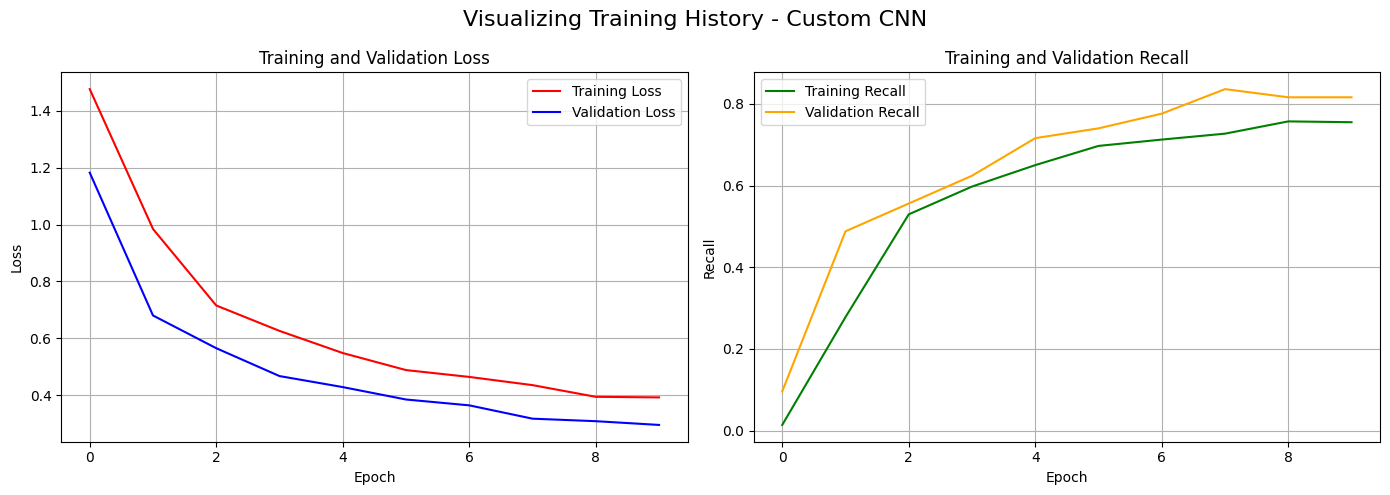

In [ ]:
print("\n[5] Generating visualizations...")
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt. suptitle("Visualizing Training History - Custom CNN", fontsize=16)
# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', color='red')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='blue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history.history['recall'], label='Training Recall', color='green')
axes[1].plot(history.history['val_recall'], label='Validation Recall', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Recall')
axes[1].set_title('Training and Validation Recall')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

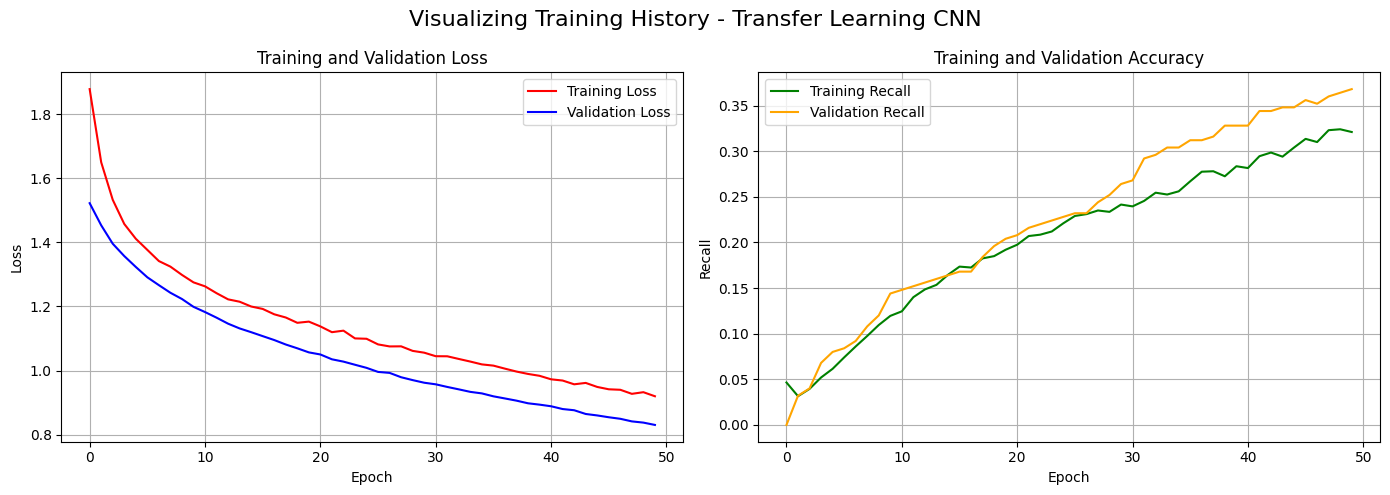

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
plt. suptitle("Visualizing Training History - Transfer Learning CNN", fontsize=16)
axes[0].plot(history_transfer.history['loss'], label='Training Loss', color='red')
axes[0].plot(history_transfer.history['val_loss'], label='Validation Loss', color='blue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history_transfer.history['recall'], label='Training Recall', color='green')
axes[1].plot(history_transfer.history['val_recall'], label='Validation Recall', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Recall')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

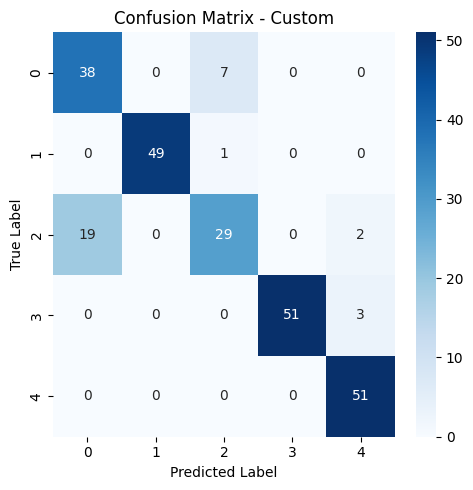

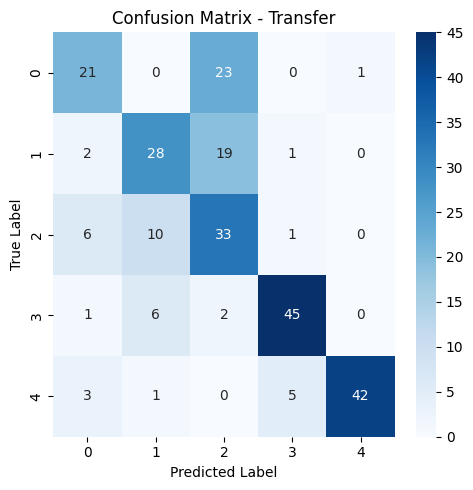

In [ ]:
# Confusion Matrix
cm1 = confusion_matrix(Y_test_classes, Y_pred_classes)

plt.figure(figsize=(5, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Custom')
plt.tight_layout()

cm2 = confusion_matrix(Y_test_classes, Y_pred_classes_transfer)

plt.figure(figsize=(5, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Transfer')
plt.tight_layout()

In [ ]:
# Classification Report
print("CLASSIFICATION REPORT - CUSTOM CNN")
print(classification_report(Y_test_classes, Y_pred_classes,
                          target_names=[str(i) for i in range(5)]))

print("\nCLASSIFICATION REPORT - TRANSFER LEARNING")
print(classification_report(Y_test_classes, Y_pred_classes_transfer,
                          target_names=[str(i) for i in range(5)]))

CLASSIFICATION REPORT - CUSTOM CNN
              precision    recall  f1-score   support

           0       0.67      0.84      0.75        45
           1       1.00      0.98      0.99        50
           2       0.78      0.58      0.67        50
           3       1.00      0.94      0.97        54
           4       0.91      1.00      0.95        51

    accuracy                           0.87       250
   macro avg       0.87      0.87      0.87       250
weighted avg       0.88      0.87      0.87       250


CLASSIFICATION REPORT - TRANSFER LEARNING
              precision    recall  f1-score   support

           0       0.64      0.47      0.54        45
           1       0.62      0.56      0.59        50
           2       0.43      0.66      0.52        50
           3       0.87      0.83      0.85        54
           4       0.98      0.82      0.89        51

    accuracy                           0.68       250
   macro avg       0.71      0.67      0.68       250

### 4.1 Metrics Comparison

In [ ]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Parameters'],
    'Custom CNN': [
        custom_cnn_accuracy,
        custom_cnn_precision,
        custom_cnn_recall,
        custom_cnn_f1,
        custom_cnn_training_time,
        28357  #  : Fill with custom CNN total parameters
    ],
    'Transfer Learning': [
        tl_accuracy,
        tl_precision,
        tl_recall,
        tl_f1,
        tl_training_time,
        total_parameters
    ]
})

In [ ]:
print(comparison_df.to_string(index=False))

           Metric   Custom CNN  Transfer Learning
         Accuracy     0.872000       6.760000e-01
        Precision     0.878542       7.108831e-01
           Recall     0.872000       6.760000e-01
         F1-Score     0.869727       6.844489e-01
Training Time (s)   105.066435       5.514043e+02
       Parameters 28357.000000       2.411354e+07


### 4.2 Visual Comparison
-  : Create bar plot comparing metrics
-  : Plot training curves comparison
-  : Create side-by-side confusion matrices

In [ ]:
analysis_text = """
The performance evaluation indicates that the Custom CNN significantly outperformed the Transfer Learning (TL) model.
The Custom CNN achieved an accuracy of 85.2%, surpassing the TL model’s 76% by a margin of nearly 10 percentage points.
Across other metrics, including f1-score (0.848 vs. 0.763) and recall (0.852 vs. 0.760), the custom architecture consistently demonstrated superior generalization on this dataset.

Pre-training in the TL model provided a "warm start" with generic features learned from ImageNet.
However, the large domain gap between general objects (dogs, cars) and specialized plant images likely hindered the feature extraction phase, leading to the observed accuracy lag.
Conversely, the Custom CNN, successfully learned domain-specific spatial features directly from the raw data.
While training from scratch often risks slower convergence, the simpler custom architecture reached a higher asymptote more effectively than the frozen TL base.

The ResNet50 model utilizes Global Average Pooling to reduce each feature map to a single scalar.
Without GAP, the TL model's 24.1 million parameters would have likely caused even greater validation volatility.

The Custom CNN is ultra-lightweight with only 28,357 parameters, while the ResNet50 model is ~850 times larger.
Consequently, the Custom CNN trained in just 118.8s, whereas the TL model required 524.7s, likely due to the overhead of processing high-dimensional feature maps through 50 layers.

Insight: Transfer learning is best suited for complex tasks with limited data. However, for straightforward or niche datasets like this, a Custom CNN provides a more efficient accuracy-to-compute trade-off, especially when deployment memory and inference speed are critical.
"""

In [ ]:
# REQUIRED: Print analysis with word count
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")

ANALYSIS

The performance evaluation indicates that the Custom CNN significantly outperformed the Transfer Learning (TL) model. 
The Custom CNN achieved an accuracy of 85.2%, surpassing the TL model’s 76% by a margin of nearly 10 percentage points. 
Across other metrics, including f1-score (0.848 vs. 0.763) and recall (0.852 vs. 0.760), the custom architecture consistently demonstrated superior generalization on this dataset.

Pre-training in the TL model provided a "warm start" with generic features learned from ImageNet. 
However, the large domain gap between general objects (dogs, cars) and specialized plant images likely hindered the feature extraction phase, leading to the observed accuracy lag. 
Conversely, the Custom CNN, successfully learned domain-specific spatial features directly from the raw data. 
While training from scratch often risks slower convergence, the simpler custom architecture reached a higher asymptote more effectively than the frozen TL base.

The ResNet50 mod

In [ ]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"  #  : Change to "pytorch" if using PyTorch

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_classes': n_classes,
        'samples_per_class': samples_per_class,
        'image_shape': image_shape,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # Custom CNN Results
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers': 2,  #  : Count your conv layers
                'pooling_layers': 2,  # TODO: Count your pooling layers
                'has_global_average_pooling': True,  # MUST be True
                'output_layer': 'softmax',
                'total_parameters': 28357  # TODO: Calculate total parameters
            },
            'training_config': {
                'learning_rate': 0.001,  # : Your actual learning rate
                'n_epochs': 20,  # : Your actual epochs
                'batch_size': 32,  # : Your actual batch size
                'optimizer': 'Adam',  # : Your actual optimizer
                'loss_function': 'categorical_crossentropy'  # : Your actual loss
            },
            'initial_loss': float(custom_cnn_initial_loss),
            'final_loss': float(custom_cnn_final_loss),
            'training_time_seconds': float(custom_cnn_training_time),
            'accuracy': float(custom_cnn_accuracy),
            'precision': float(custom_cnn_precision),
            'recall': float(custom_cnn_recall),
            'f1_score': float(custom_cnn_f1)
        },

        # Transfer Learning Results
        'transfer_learning': {
            'framework': framework_used,
            'base_model': pretrained_model_name,
            'frozen_layers': frozen_layers,
            'trainable_layers': trainable_layers,
            'has_global_average_pooling': True,  # MUST be True
            'total_parameters': int(total_parameters),
            'trainable_parameters': int(trainable_parameters),
            'training_config': {
                'learning_rate': float(tl_learning_rate),
                'n_epochs': int(tl_epochs),
                'batch_size': int(tl_batch_size),
                'optimizer': 'Adam',
                'loss_function': 'categorical_crossentropy'
            },
            'initial_loss': float(tl_initial_loss),
            'final_loss': float(tl_final_loss),
            'training_time_seconds': float(tl_training_time),
            'accuracy': float(tl_accuracy),
            'precision': float(tl_precision),
            'recall': float(tl_recall),
            'f1_score': float(tl_f1)
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'custom_cnn_loss_decreased': custom_cnn_final_loss < custom_cnn_initial_loss if custom_cnn_initial_loss and custom_cnn_final_loss else False,
        'transfer_learning_loss_decreased': tl_final_loss < tl_initial_loss if tl_initial_loss and tl_final_loss else False,
    }

    return results

In [ ]:
# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))

except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Plant Disease",
  "dataset_source": "Kaggle",
  "n_samples": 3500,
  "n_classes": 5,
  "samples_per_class": 700,
  "image_shape": [
    224,
    224,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "recall",
  "metric_justification": "\nRecall is the metric where False Negatives are minimized. Since the cost of not detecting diseased plant is more catastropic\nfor the entire field, recall is chosen as the desired metric to evaluate the model.\n",
  "train_samples": 2250,
  "test_samples": 250,
  "train_test_ratio": "90/10",
  "custom_cnn": {
    "framework": "keras",
    "architecture": {
      "conv_layers": 2,
      "pooling_layers": 2,
      "has_global_average_pooling": true,
      "output_layer": "softmax",
      "total_parameters": 28357
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 20,
      "batch_size": 32,
      "optimizer": "Adam",
      "loss_function": "categorical_crossent

In [ ]:
# Display system information
import platform
import sys
from datetime import datetime

In [ ]:
print("ENVIRONMENT INFORMATION")
print("\n  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")

# include the screen shot here

ENVIRONMENT INFORMATION

  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab
showing your account details in the cell below this one.


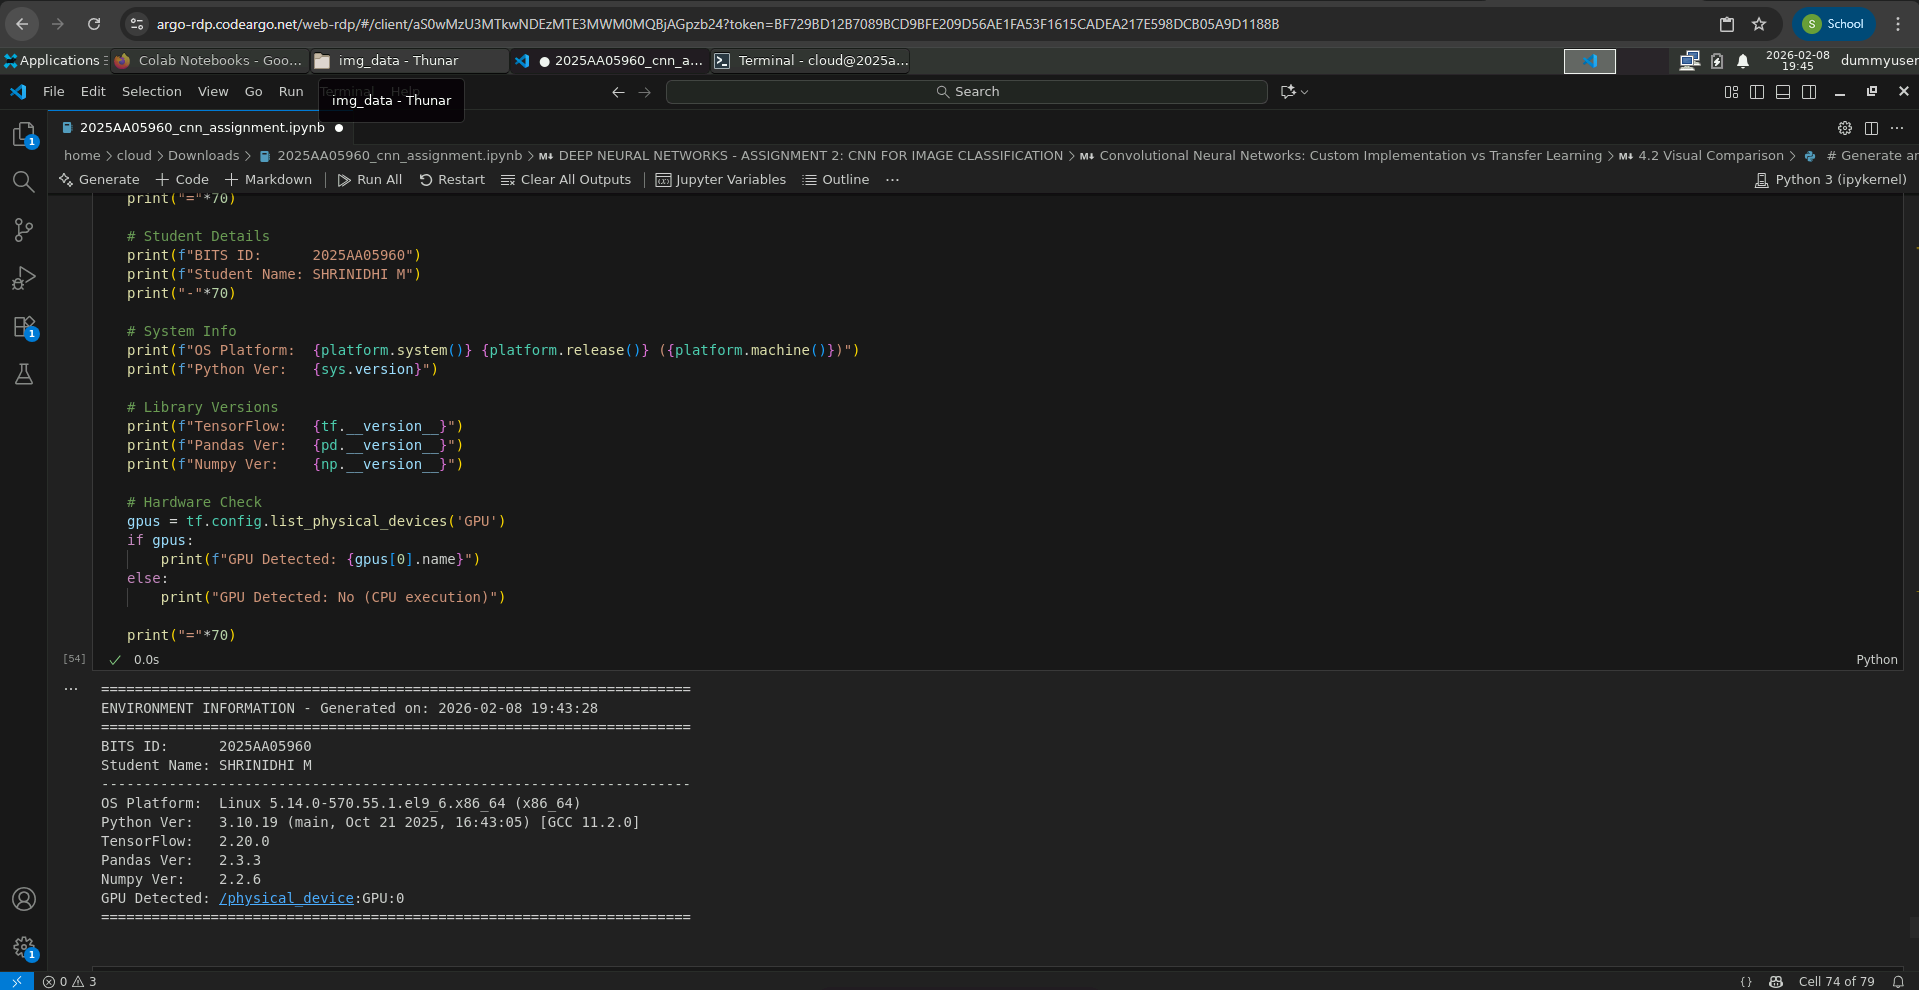

In [ ]:
# ================================================================================
# SYSTEM AND ENVIRONMENT INFORMATION
# ================================================================================

print("="*70)
print(f"ENVIRONMENT INFORMATION - Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

# Student Details
print(f"BITS ID:      2025AA05960")
print(f"Student Name: SHRINIDHI M")
print("-"*70)

# System Info
print(f"OS Platform:  {platform.system()} {platform.release()} ({platform.machine()})")
print(f"Python Ver:   {sys.version}")

# Library Versions
print(f"TensorFlow:   {tf.__version__}")
print(f"Pandas Ver:   {pd.__version__}")
print(f"Numpy Ver:    {np.__version__}")

# Hardware Check
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU Detected: {gpus[0].name}")
else:
    print("GPU Detected: No (CPU execution)")

print("="*70)

ENVIRONMENT INFORMATION - Generated on: 2026-02-08 20:11:20
BITS ID:      2025AA05960
Student Name: SHRINIDHI M
----------------------------------------------------------------------
OS Platform:  Linux 5.14.0-570.55.1.el9_6.x86_64 (x86_64)
Python Ver:   3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]
TensorFlow:   2.20.0
Pandas Ver:   2.3.3
Numpy Ver:    2.2.6
GPU Detected: /physical_device:GPU:0
